In [1]:
import h5py
from gwpy.plot import Plot
from gwpy.timeseries import TimeSeries
from numpy.random import randint
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors

### SNR 10 data

In [3]:
fpath = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/ai4gw@cern/bns_snr_10_256Hz_100K/test/sig_combined_test.h5'
fdata = h5py.File(fpath, 'r')

In [5]:
injected_data = fdata['whitened_injected']
sig_only_data = fdata['whitened_signal']
bkg_only_data = fdata['whitened_bkg']

In [5]:
i, j = randint(0, 1000), randint(0, 2)

In [7]:
ts_injected_data = TimeSeries(injected_data[i][j], sample_rate=256)
ts_sig_only_data = TimeSeries(sig_only_data[i][j], sample_rate=256)
ts_bkg_only_data = TimeSeries(bkg_only_data[i][j], sample_rate=256)

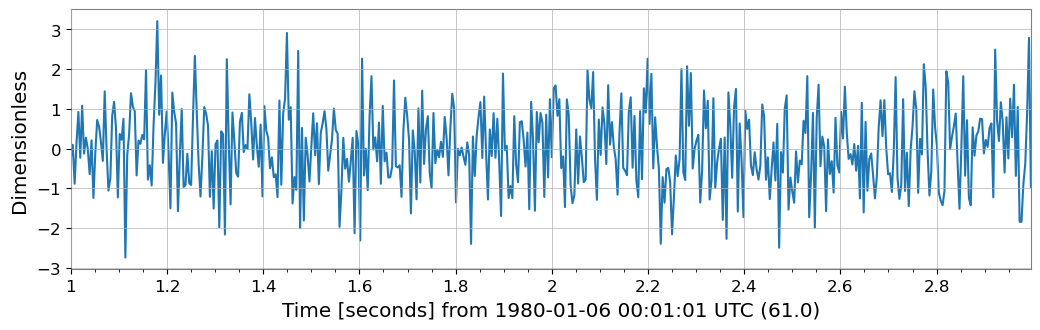

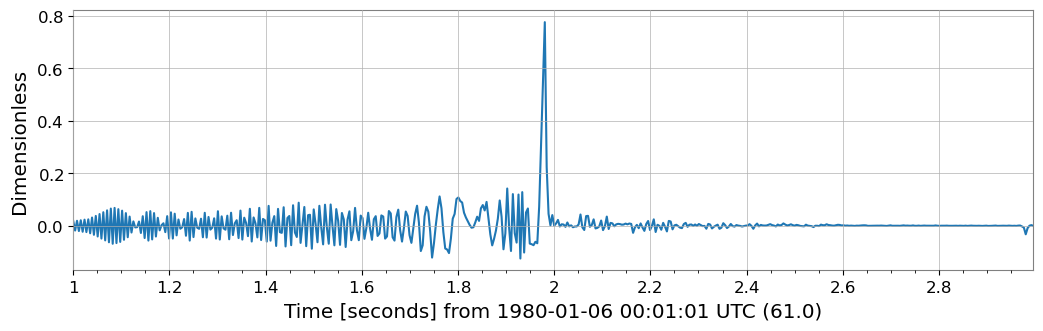

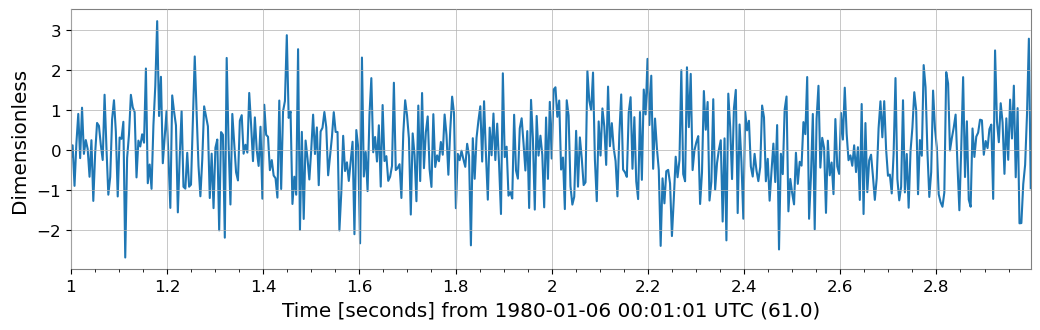

In [8]:
plot_injected_data = ts_injected_data[62*256:64*256].plot()
plot_sig_only_data = ts_sig_only_data[62*256:64*256].plot()
plot_bkg_only_data = ts_bkg_only_data[62*256:64*256].plot()

In [9]:
l1_0 = sig_only_data[0][0]
h1_0 = sig_only_data[0][1]
dec_0 = fdata['dec'][0]
phi_0 = fdata['phi'][0]
mc_0  = fdata['chirp_mass'][0]
ts_l1_0 = TimeSeries(l1_0, sample_rate=256)
ts_h1_0 = TimeSeries(h1_0, sample_rate=256)

In [10]:
print(dec_0, phi_0, mc_0)

-1.110916 -3.1342626 1.2478273


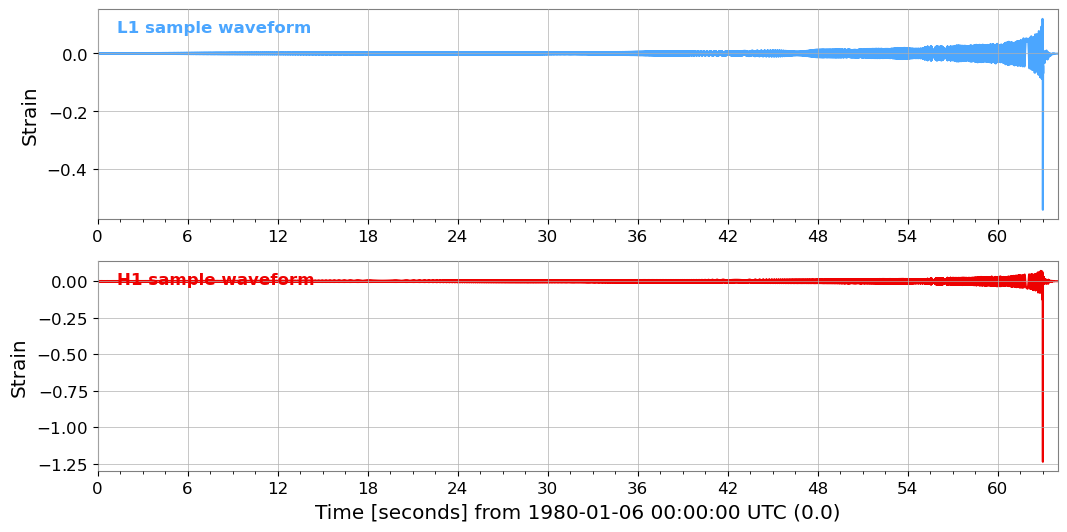

In [11]:
plot = Plot(ts_l1_0[::2], ts_h1_0[::2], separate=True, sharex=True)
colors = ['gwpy:ligo-livingston', 'gwpy:ligo-hanford']
labels = ['L1 sample waveform', 'H1 sample waveform']

for ax, color, label in zip(plot.axes, colors, labels):
    ax.lines[0].set_color(color)
    # Place text in top-left corner of each subplot
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        color=color,
        va='top'
    )
    ax.set_ylabel('Strain')
plot.show()

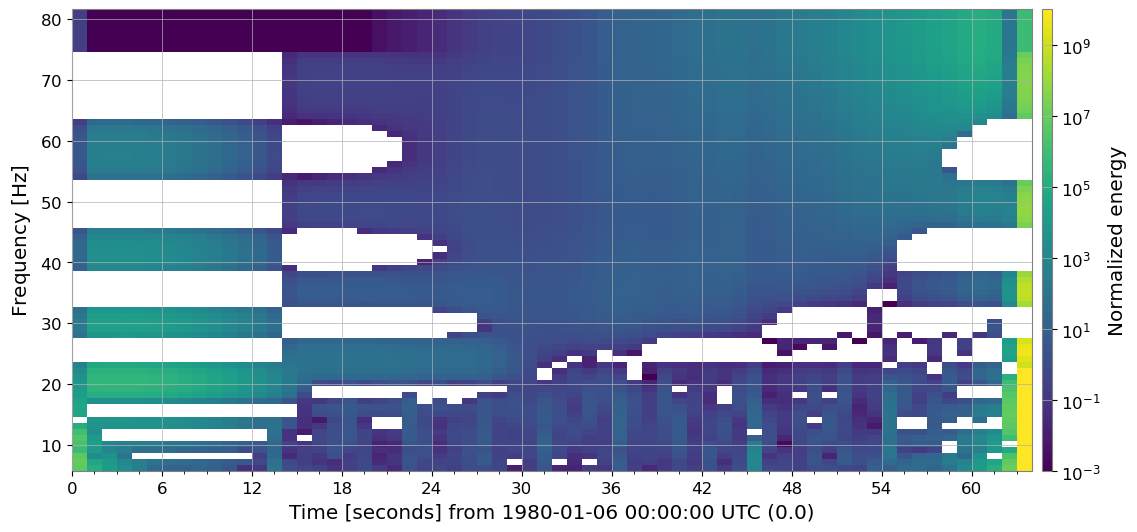

In [14]:
plot_q_ts_l1_0 = ts_l1_0.q_transform(tres=1, fres=1).plot()
ax = plot_q_ts_l1_0.gca()
ax.colorbar(norm=pltcolors.LogNorm(vmin=1e-3, vmax=1e10), label='Normalized energy')
plot_q_ts_l1_0.show()
plot_q_ts_l1_0.show()

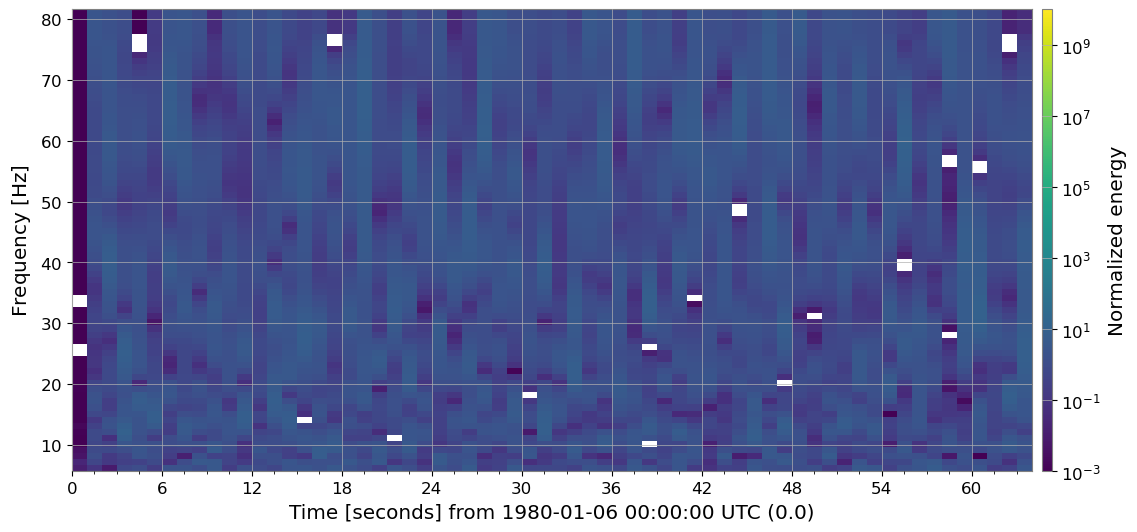

In [16]:
plot_q_ts_l1_0_bkg = TimeSeries(bkg_only_data[0][0], sample_rate=256).q_transform(tres=1, fres=1).plot()
ax = plot_q_ts_l1_0_bkg.gca()
ax.colorbar(norm=pltcolors.LogNorm(vmin=1e-3, vmax=1e10), label='Normalized energy')
plot_q_ts_l1_0_bkg.show()

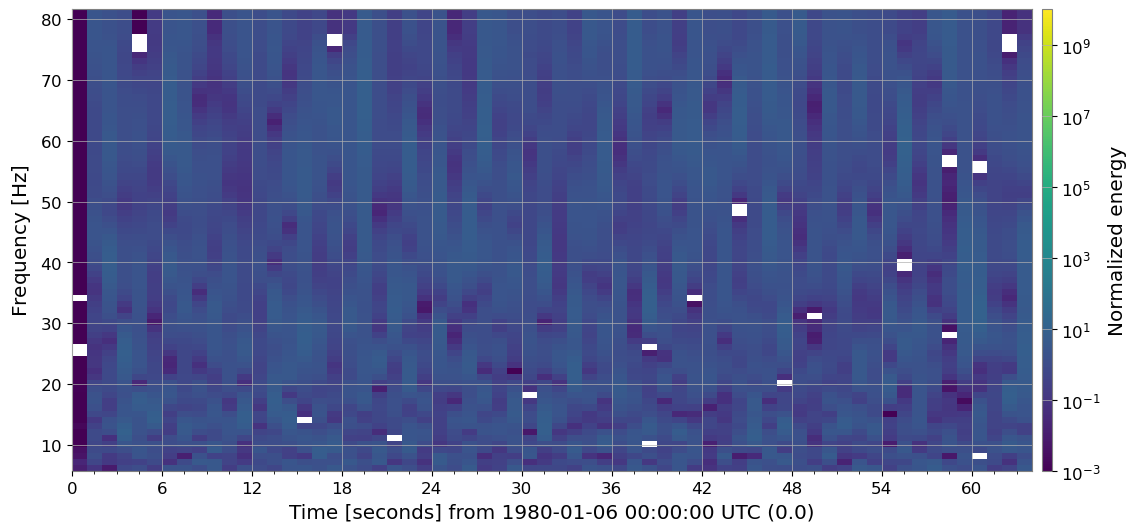

In [17]:
plot_q_ts_l1_0_inj = TimeSeries(injected_data[0][0], sample_rate=256).q_transform(tres=1, fres=1).plot()
ax = plot_q_ts_l1_0_inj.gca()
ax.colorbar(norm=pltcolors.LogNorm(vmin=1e-3, vmax=1e10), label='Normalized energy')
plot_q_ts_l1_0_inj.show()

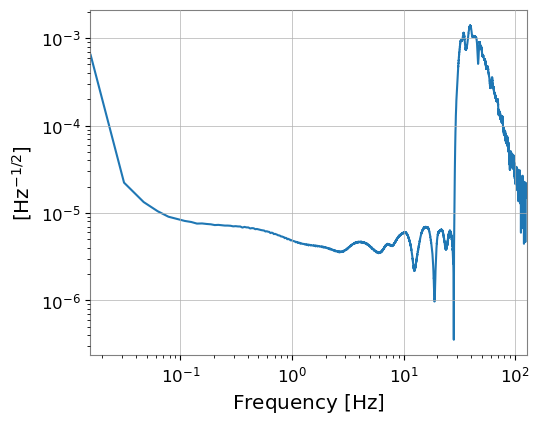

In [18]:
plot_asd_ts_l1_0 = ts_l1_0.asd().plot()
plot_asd_ts_l1_0.show()

In [19]:
def gw_freq(m_chirp, t_to_merger):
    return 134 * np.power(1.21/m_chirp, 5/8) * np.power(1/t_to_merger, 3/8)

/tmp/ipykernel_3728001/18493278.py:2: RuntimeWarning: divide by zero encountered in divide
  return 134 * np.power(1.21/m_chirp, 5/8) * np.power(1/t_to_merger, 3/8)


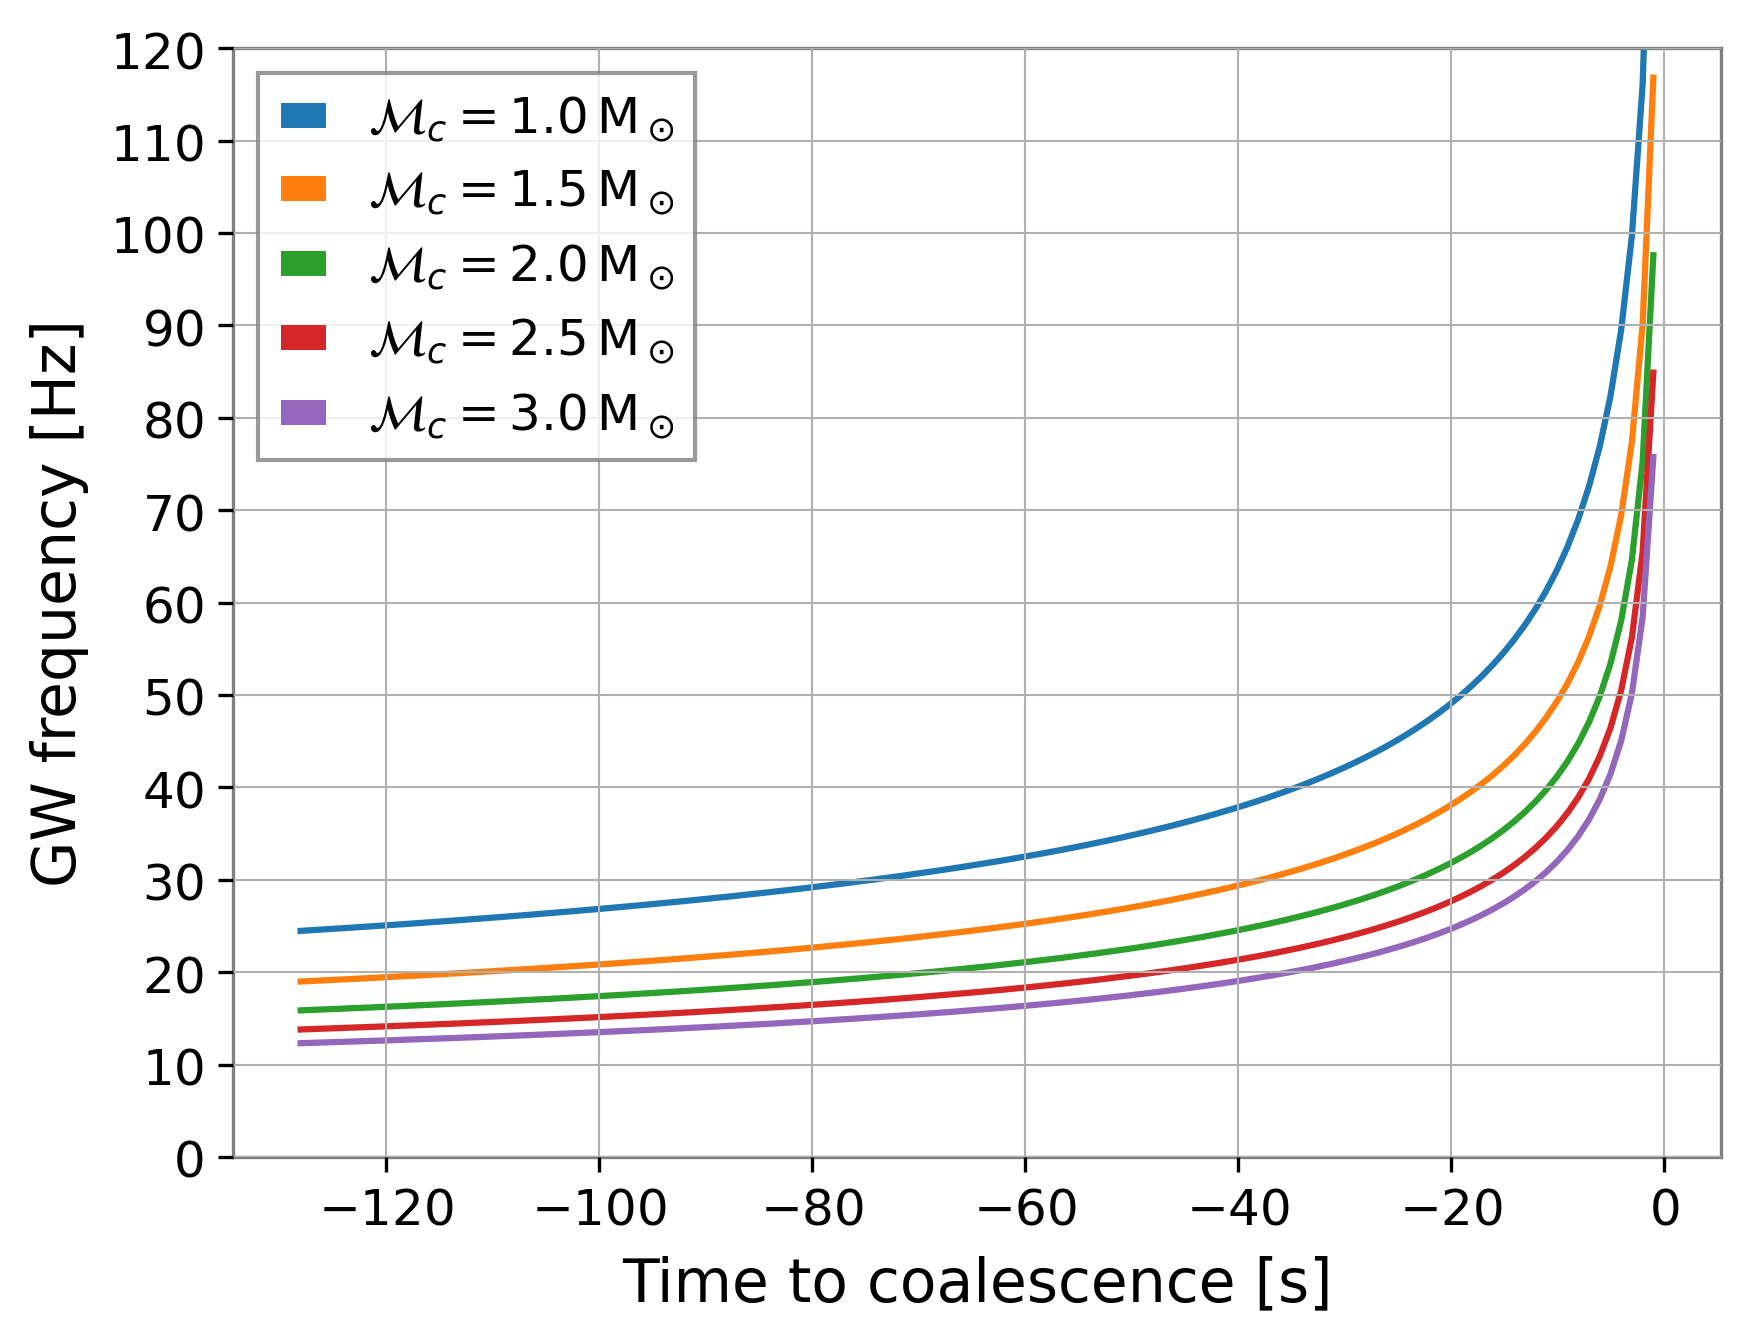

In [20]:
m_chirps = [1.0, 1.5, 2.0, 2.5, 3.0]
t_to_merger = np.linspace(128, 0, 128)
gw_freqs = [gw_freq(mc, t_to_merger) for mc in m_chirps]
plt.figure(dpi=300)
for i in range(len(gw_freqs)):
    plt.plot(-t_to_merger, gw_freqs[i], label=fr'$\mathcal{{M}}_c={m_chirps[i]:.1f}\,\mathrm{{M}}_\odot$')
plt.ylim(0, 120)
plt.xlabel('Time to coalescence [s]')
plt.ylabel('GW frequency [Hz]')
plt.yticks(np.linspace(0, 120, 13, endpoint=True))
plt.legend()
plt.show()

#### Prior plots

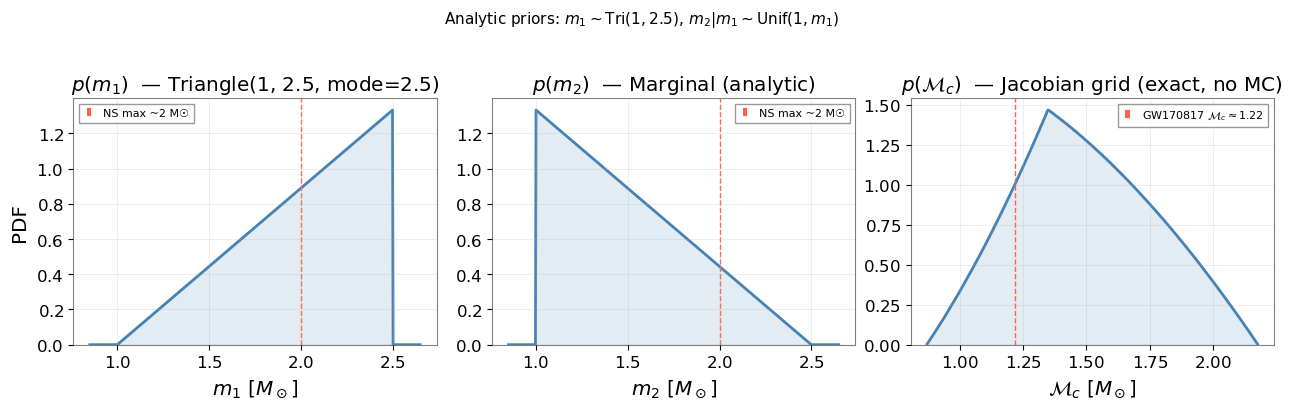

Mc range: [0.871, 2.176] M_sun
p(Mc) integral check: 1.001001


In [21]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 1.0, 2.5           # component mass range
area = (b - a)**2 / 2     # area of valid (m1,m2) triangle region
C = 1.0 / area            # joint density constant = 8/9

# ── Analytic PDFs ──────────────────────────────────────────────

def p_m1(m1):
    '''Triangle(lower=1, upper=2.5, mode=2.5): rising linear.'''
    out = np.zeros_like(m1, dtype=float)
    mask = (m1 >= a) & (m1 <= b)
    out[mask] = 2*(m1[mask] - a) / (b - a)**2
    return out

def p_m2_marginal(m2):
    '''Marginal of m2 after integrating out m1. Falling linear.'''
    out = np.zeros_like(m2, dtype=float)
    mask = (m2 >= a) & (m2 <= b)
    out[mask] = 2*(b - m2[mask]) / (b - a)**2
    return out

def chirp_mass(m1, m2):
    return (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

# ── p(Mc) via exact Jacobian grid integration ──────────────────
# Joint p(m1,m2)=C is uniform on {a<=m2<=m1<=b}.
# Evaluate chirp mass at every grid point, weighted by C*dm^2.

N = 3000
m1v = np.linspace(a, b, N)
m2v = np.linspace(a, b, N)
M1, M2 = np.meshgrid(m1v, m2v, indexing='ij')
valid = M2 <= M1     # enforce m2 <= m1

dm = (b - a) / (N - 1)
Mc_flat = chirp_mass(M1[valid], M2[valid])
weights  = np.full(Mc_flat.shape, C * dm**2)

mc_min, mc_max = Mc_flat.min(), Mc_flat.max()
n_bins = 400
bins = np.linspace(mc_min, mc_max, n_bins + 1)
hist, edges = np.histogram(Mc_flat, bins=bins, weights=weights)
bw = edges[1] - edges[0]
mc_pdf = hist / bw            # p(Mc): integrates to 1
mc_centers = (edges[:-1] + edges[1:]) / 2

# ── Plot ───────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
kw = dict(lw=2, color='steelblue')

# m1
m1x = np.linspace(0.85, 2.65, 600)
axes[0].plot(m1x, p_m1(m1x), **kw)
axes[0].fill_between(m1x, p_m1(m1x), alpha=0.15, color='steelblue')
axes[0].set(title=r'$p(m_1)$  — Triangle(1, 2.5, mode=2.5)',
            xlabel=r'$m_1\ [M_\odot]$', ylabel='PDF')
axes[0].axvline(2.0, ls='--', lw=1, color='tomato', label='NS max ~2 M☉')
axes[0].legend(fontsize=8)

# m2
m2x = np.linspace(0.85, 2.65, 600)
axes[1].plot(m2x, p_m2_marginal(m2x), **kw)
axes[1].fill_between(m2x, p_m2_marginal(m2x), alpha=0.15, color='steelblue')
axes[1].set(title=r'$p(m_2)$  — Marginal (analytic)',
            xlabel=r'$m_2\ [M_\odot]$')
axes[1].axvline(2.0, ls='--', lw=1, color='tomato', label='NS max ~2 M☉')
axes[1].legend(fontsize=8)

# Mc
axes[2].plot(mc_centers, mc_pdf, **kw)
axes[2].fill_between(mc_centers, mc_pdf, alpha=0.15, color='steelblue')
axes[2].set(title=r'$p(\mathcal{M}_c)$  — Jacobian grid (exact, no MC)',
            xlabel=r'$\mathcal{M}_c\ [M_\odot]$')
bns_mc = chirp_mass(1.4, 1.4)
axes[2].axvline(bns_mc, ls='--', lw=1, color='tomato',
                label=rf'GW170817 $\mathcal{{M}}_c \approx {bns_mc:.2f}$')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle(r'Analytic priors: $m_1\sim\mathrm{Tri}(1,2.5)$, $m_2|m_1\sim\mathrm{Unif}(1,m_1)$',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('gw_priors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mc range: [{mc_min:.3f}, {mc_max:.3f}] M_sun')
print(f'p(Mc) integral check: {(mc_pdf * bw).sum():.6f}')  # should be ~1

### SNR 10 data: denoised, mse loss

In [2]:
fpath_den = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/ai4gw@cern/bns_snr_10_256Hz_100K/denoised/seq_denoise_0-4s_d256_s64_l4/denoised_sig_combined_test.h5'
fdata_den = h5py.File(fpath_den, 'r')

In [3]:
injected_data_den = fdata_den['whitened_injected']
sig_only_data_den = fdata_den['whitened_signal']
bkg_only_data_den = fdata_den['whitened_bkg']

In [6]:
ts_injected_data_den = TimeSeries(injected_data_den[i][j], sample_rate=256)
ts_sig_only_data_den = TimeSeries(sig_only_data_den[i][j], sample_rate=256)
ts_bkg_only_data_den = TimeSeries(bkg_only_data_den[i][j], sample_rate=256)

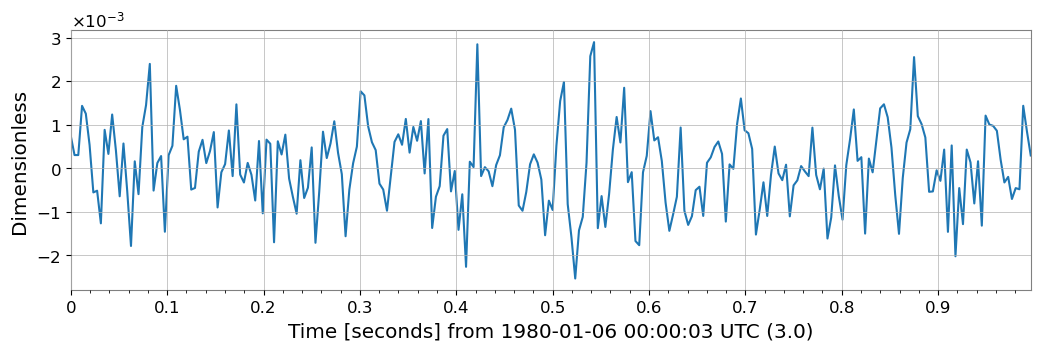

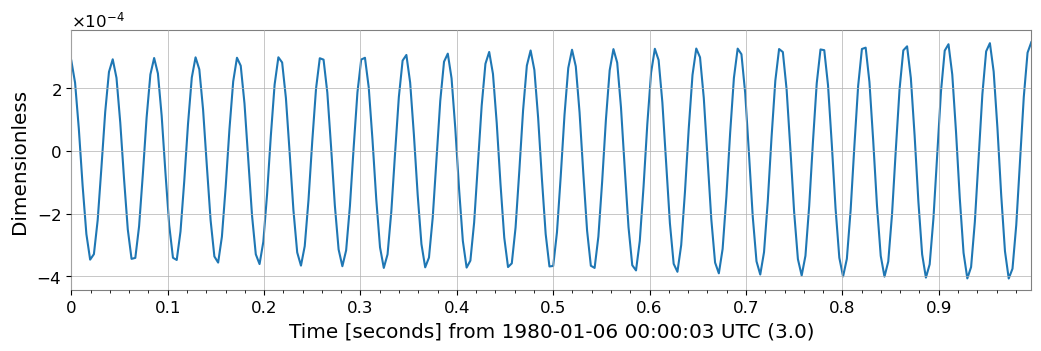

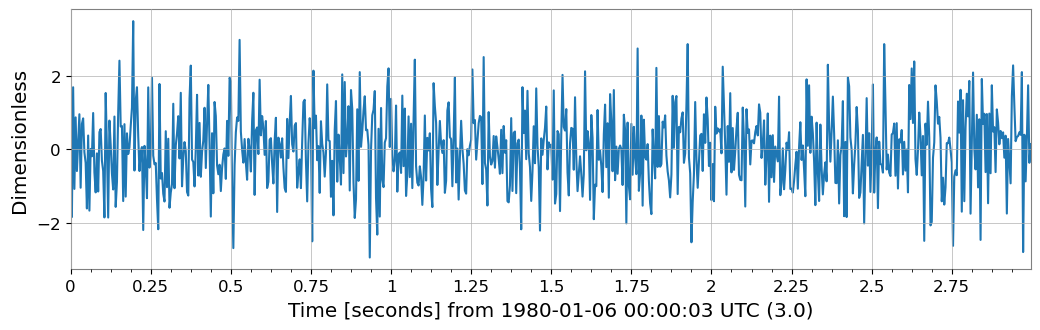

In [9]:
plot_injected_data_den = ts_injected_data_den[int(3*256):int(6*256)].plot()
plot_sig_only_data_den = ts_sig_only_data_den[int(3*256):int(6*256)].plot()
plot_bkg_only_data_den = ts_bkg_only_data_den[int(3*256):int(6*256)].plot()

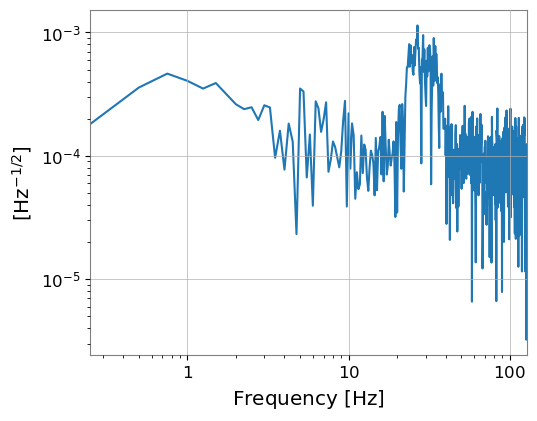

In [10]:
plot_injected_data_den = ts_injected_data_den.asd().plot()
plot_injected_data_den.show()

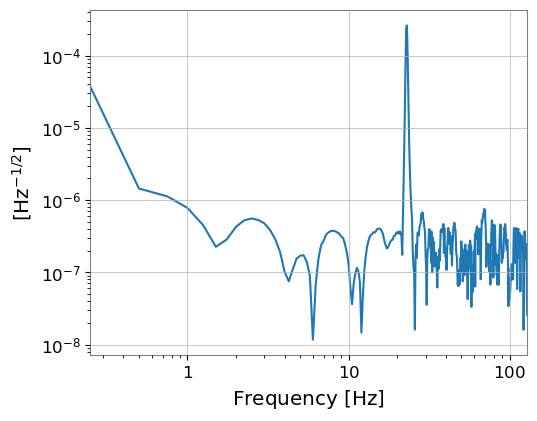

In [11]:
plot_sig_only_data_den = ts_sig_only_data_den.asd().plot()
plot_sig_only_data_den.show()

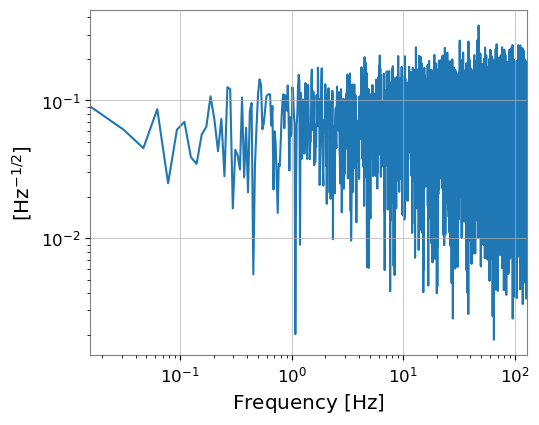

In [12]:
plot_bkg_only_data_den = ts_bkg_only_data_den.asd().plot()
plot_bkg_only_data_den.show()

### SNR 10 data: denoised, psd loss